# Week 8 · Day 1 — Class
# What is Machine Learning? Your First Model 🤖

Welcome to the **final week**! You've come a long way: Python, data structures, NumPy, Pandas, cleaning, and visualization. Today all of that pays off.

Until now, **you** wrote the rules. Today the **computer learns the rules from data**. That's Machine Learning.

**In this class we will:**
1. Understand what ML really is (with a simple picture).
2. Learn the words: *features*, *target*, *train*, *test*.
3. Build our very first model on the classic **Iris flowers** dataset.
4. Make predictions and check how good our model is.

No hard math. Just intuition and code. Let's go! 🚀

## 1. What is Machine Learning?

Think about how you'd tell a cat from a dog in code.

**The old way (writing rules by hand):**
```
if has_whiskers and says_meow:
    it_is_a_cat()
```
This gets messy fast. Real life has thousands of exceptions.

**The Machine Learning way:**
> Instead of writing rules, we **show the computer many labeled examples** (this is a cat, this is a dog), and it **figures out the rules by itself**.

That's the whole idea:

**Data + Answers → Model → Predictions on new data**

The model *learns patterns from examples*, then uses those patterns on data it has never seen.

## 2. The words you need (just four)

| Word | Plain meaning | Iris example |
|------|---------------|--------------|
| **Feature (X)** | The inputs / clues we measure | petal length, petal width, ... |
| **Target (y)** | The answer we want to predict | the flower *species* |
| **Train** | The examples the model learns from | 80% of the flowers |
| **Test** | Fresh examples to check the model | the other 20% |

Two kinds of ML problems we'll meet:
- **Classification** → predict a *category* (which species? cat or dog? survived or not?)
- **Regression** → predict a *number* (house price, temperature)

Today is **classification**.

In [1]:
# Our familiar toolkit first
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Load the classic Iris dataset (comes with seaborn)
iris = sns.load_dataset("iris")

# Always look before you leap
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [2]:
# How big is it? Any missing values?
print("Shape:", iris.shape)
print()
print(iris.info())

Shape: (150, 5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None


In [3]:
# What are we trying to predict? The 'species' column.
iris["species"].value_counts()

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

### A quick look at the pattern

Before any ML, let's *see* why this is even possible. If the flower species form separate groups when we plot them, a model can learn to separate them too.

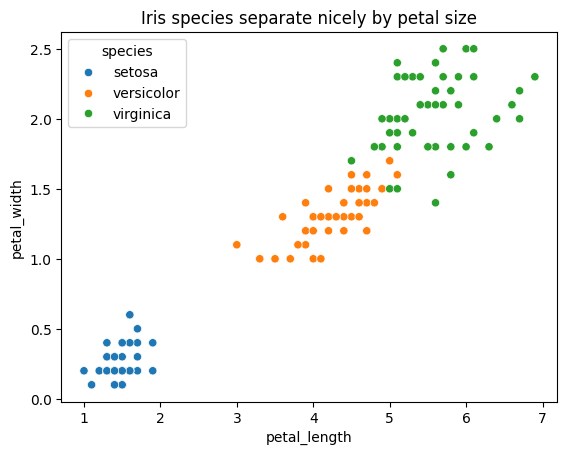

In [4]:
# Color each species differently and plot two features
sns.scatterplot(data=iris, x="petal_length", y="petal_width", hue="species")
plt.title("Iris species separate nicely by petal size")
plt.show()

Notice the three colored clouds barely overlap. **That separation is exactly what our model will learn.** 👀

## 3. Step 1 — Split into Features (X) and Target (y)

- **X** = the measurement columns (the clues)
- **y** = the species column (the answer)

In [5]:
# Features: the four measurement columns
X = iris[["sepal_length", "sepal_width", "petal_length", "petal_width"]]

# Target: what we want to predict
y = iris["species"]

print("X shape:", X.shape)   # 150 rows, 4 feature columns
print("y shape:", y.shape)   # 150 answers
X.head()

X shape: (150, 4)
y shape: (150,)


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [6]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

## 4. Step 2 — Split into Train and Test

**Golden rule of ML:** never test your model on the same data it learned from.

Why? Because memorizing the answers isn't the same as *understanding*. If you study the exact exam questions beforehand, a 100% score proves nothing. So we hide some data from the model and only use it to grade at the end.

`scikit-learn` gives us a one-liner for this.

In [ ]:
!pip install scikit-learn -q

In [8]:
X

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [9]:
y

0         setosa
1         setosa
2         setosa
3         setosa
4         setosa
         ...    
145    virginica
146    virginica
147    virginica
148    virginica
149    virginica
Name: species, Length: 150, dtype: object

In [10]:
from sklearn.model_selection import train_test_split

# Keep 20% of the data aside for testing.
# random_state=42 just makes the split reproducible (same result every run).
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training examples:", X_train.shape[0])
print("Testing examples: ", X_test.shape[0])

Training examples: 120
Testing examples:  30


In [11]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


In [15]:
y_train

22         setosa
15         setosa
65     versicolor
11         setosa
42         setosa
          ...    
71     versicolor
106     virginica
14         setosa
92     versicolor
102     virginica
Name: species, Length: 120, dtype: object

In [14]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4
31,5.4,3.4,1.5,0.4
64,5.6,2.9,3.6,1.3
141,6.9,3.1,5.1,2.3
68,6.2,2.2,4.5,1.5
82,5.8,2.7,3.9,1.2


## 5. Step 3 — Choose a model and `.fit()` it

We'll use **K-Nearest Neighbors (KNN)** — the most intuitive model there is.

**How KNN thinks:** to classify a new flower, it looks at the *k* closest flowers it already knows and takes a vote. If the 5 nearest flowers are mostly *setosa*, it guesses *setosa*. That's it — "you are like your neighbors."

`.fit()` is the word for **"learn from the training data."**

In [16]:
from sklearn.neighbors import KNeighborsClassifier

# Create the model. n_neighbors=5 means "look at the 5 closest flowers".
model = KNeighborsClassifier(n_neighbors=5)

# Learn from the training data
model.fit(X_train, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](3,)","['setosa','versicolor','virginica']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


## 6. Step 4 — `.predict()` on the test set

Now we ask the trained model to guess the species for flowers **it has never seen**.

In [17]:
X_test

,sepal_length,sepal_width,petal_length,petal_width
73,6.1,2.8,4.7,1.2
18,5.7,3.8,1.7,0.3
118,7.7,2.6,6.9,2.3
78,6.0,2.9,4.5,1.5
76,6.8,2.8,4.8,1.4
31,5.4,3.4,1.5,0.4
64,5.6,2.9,3.6,1.3
141,6.9,3.1,5.1,2.3
68,6.2,2.2,4.5,1.5
82,5.8,2.7,3.9,1.2


In [18]:
y_test

73     versicolor
18         setosa
118     virginica
78     versicolor
76     versicolor
31         setosa
64     versicolor
141     virginica
68     versicolor
82     versicolor
110     virginica
12         setosa
36         setosa
9          setosa
19         setosa
56     versicolor
104     virginica
69     versicolor
55     versicolor
132     virginica
29         setosa
127     virginica
26         setosa
128     virginica
131     virginica
145     virginica
108     virginica
143     virginica
45         setosa
30         setosa
Name: species, dtype: object

In [19]:
# Predict species for the held-out test flowers
predictions = model.predict(X_test)

# Compare the first 10: what the model guessed vs the truth
compare = pd.DataFrame({
    "predicted": predictions[:10],
    "actual": y_test.values[:10]
})
compare

,predicted,actual
0,versicolor,versicolor
1,setosa,setosa
2,virginica,virginica
3,versicolor,versicolor
4,versicolor,versicolor
5,setosa,setosa
6,versicolor,versicolor
7,virginica,virginica
8,versicolor,versicolor
9,versicolor,versicolor


## 7. Step 5 — Score: how good is it?

**Accuracy** = (correct guesses) / (total guesses). Simple and honest for a balanced dataset like this.

In [20]:
from sklearn.metrics import accuracy_score

acc = accuracy_score(y_test, predictions)
print(f"Accuracy: {acc:.2f}  ->  {acc*100:.0f}% correct")

Accuracy: 1.00  ->  100% correct


## 8. Predict on a brand-new flower 🌸

The real magic: hand the model measurements it has never seen and get an instant guess.

In [24]:
# A made-up flower: [sepal_length, sepal_width, petal_length, petal_width]
new_flower = pd.DataFrame(
    [[5.2, 3.6, 1.5, 0.3]],
    columns=["sepal_length", "sepal_width", "petal_length", "petal_width"]
)

new_flower

,sepal_length,sepal_width,petal_length,petal_width
0,5.2,3.6,1.5,0.3


In [27]:
guess = model.predict(new_flower)
print("The model thinks this flower is:", guess[0])

The model thinks this flower is: setosa


In [23]:
iris

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


## 🎯 What you learned today

You built a complete ML model in **five steps**:

1. **Split X / y** — features vs the target
2. **Train / test split** — hide some data for honest grading
3. **`.fit()`** — the model learns patterns
4. **`.predict()`** — guess on unseen data
5. **`accuracy_score`** — how often it's right

This exact 5-step recipe works for almost every classification problem. Next class we'll practice it on a dataset you already know — the **Titanic**. See you there! 🚢